In [3]:
### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner
import seaborn as sns
import matplotlib.gridspec as gridspec

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

tf.config.experimental.set_memory_growth(physical_devices[0], True)

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

modelpath = '/home/hatte/M4/models'

Current GPU usage:
 - GPU0: 0B



In [5]:
n_layers = [2,4,6,8]
units = [32,64,128,256,512]
loss_func = ['MSE']
Nepochs = 200
learning_rate = 0.001
arch_df = pd.DataFrame(product(n_layers,units,loss_func))
arch_df['med_loss'] = np.zeros_like(arch_df[0].values)
arch_df['std_loss'] = np.zeros_like(arch_df[0].values)

In [31]:
for i in arch_df.index:
    ######## define architecture:
    model_name = 'simple_network'
    n_dense_layers = arch_df.loc[i, 0] #number of dense layers
    dense_layer_units = arch_df.loc[i, 1] #neurons per dense layer
    loss_func = arch_df.loc[i, 2]

    ###### Checkpointing
    historyfile = f'short-run-tests/history/hist-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.json'
    hist = pd.read_json(f'{modelpath}/{historyfile}')
    arch_df.loc[i, 'med_loss'] = np.median(hist['loss'][-30:].values)
    arch_df.loc[i, 'std_loss'] = np.std(hist['loss'][-30:].values)

In [32]:
piv_med = arch_df.pivot(index = 0,columns = 1,values = 'med_loss')

piv_std = arch_df.pivot(index = 0,columns = 1,values = 'std_loss')


In [35]:
arch_df['std_loss'].min()

np.float64(2.2499488071970998e-05)

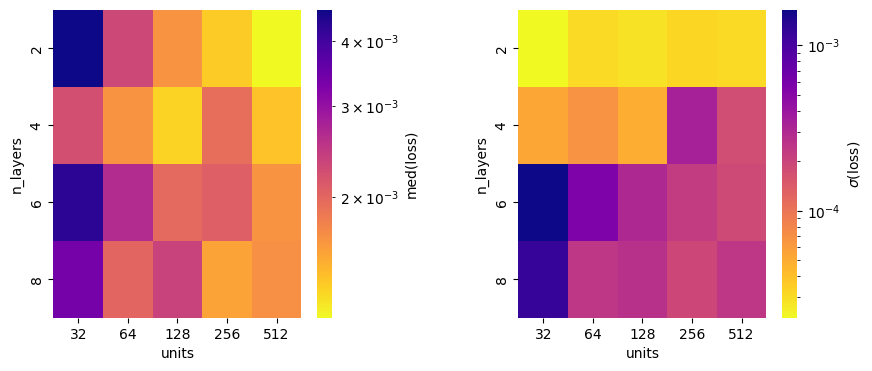

In [38]:
from matplotlib.colors import LogNorm


fig = plt.figure(figsize = (10, 4))
gs = gridspec.GridSpec(1, 2, wspace = 0.5)
ax_med = fig.add_subplot(gs[0, 0])
ax_std = fig.add_subplot(gs[0, 1])

fig_med = sns.heatmap(piv_med,cmap='plasma_r',cbar_kws={'label': r'med(loss)'}, ax = ax_med, norm=LogNorm(vmin=arch_df['med_loss'].min(), vmax=arch_df['med_loss'].max()))
fig_std = sns.heatmap(piv_std,cmap='plasma_r',cbar_kws={'label': r'$\sigma$(loss)'}, ax = ax_std, norm=LogNorm(vmin=arch_df['std_loss'].min(), vmax=arch_df['std_loss'].max()))

fig_med.set(xlabel='units', ylabel='n_layers')
fig_std.set(xlabel='units', ylabel='n_layers')

fig.savefig('../figs/short-run-grid.png', bbox_inches = 'tight', dpi = 150)

In [29]:
np.log10(0.0012)

np.float64(-2.9208187539523753)